1. Download Repo dari github

In [1]:
repos = {
"storm":"https://github.com/apache/storm.git",
"butterknife":"https://github.com/JakeWharton/butterknife.git",
"crate":"https://github.com/crate/crate.git",
"hystrix":"https://github.com/Netflix/Hystrix.git",
"jabref":"https://github.com/JabRef/jabref.git",
"jcabi":"https://github.com/jcabi/jcabi-github.git",
"openmicroscopy":"https://github.com/ome/openmicroscopy.git",
"presto":"https://github.com/prestodb/presto.git",
"rxandroid":"https://github.com/ReactiveX/RxAndroid.git",
"sponge":"https://github.com/SpongePowered/SpongeAPI.git",
"springboot":"https://github.com/spring-projects/spring-boot.git",
"okhttp":"https://github.com/square/okhttp.git",
"retrofit":"https://github.com/square/retrofit.git",
"wordpress":"https://github.com/wordpress-mobile/WordPress-Android.git"
}

for name,url in repos.items():
    !git clone --depth 1 {url} repos/{name}

Cloning into 'repos/storm'...
remote: Enumerating objects: 3868, done.
remote: Counting objects: 100% (3868/3868), done.
remote: Compressing objects: 100% (2941/2941), done.
remote: Total 3868 (delta 1304), reused 1913 (delta 528), pack-reused 0 (from 0)
Receiving objects: 100% (3868/3868), 33.78 MiB | 6.93 MiB/s, done.
Resolving deltas: 100% (1304/1304), done.
Cloning into 'repos/butterknife'...
remote: Enumerating objects: 378, done.
remote: Counting objects: 100% (378/378), done.
remote: Compressing objects: 100% (287/287), done.
remote: Total 378 (delta 90), reused 185 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (378/378), 1.54 MiB | 7.56 MiB/s, done.
Resolving deltas: 100% (90/90), done.
Cloning into 'repos/crate'...
remote: Enumerating objects: 6891, done.
remote: Counting objects: 100% (6891/6891), done.
remote: Compressing objects: 100% (5323/5323), done.
remote: Total 6891 (delta 2896), reused 2618 (delta 1187), pack-reused 0 (from 0)
Receiving objects: 100% (68

2. Menghitung jumlah file setiap repository

In [2]:
import os
import pandas as pd

def count_files(repo_path):
    total_files = 0
    for root, dirs, files in os.walk(repo_path):
        total_files += len(files)
    return total_files

summary = []

for name in repos.keys():
    path = f"repos/{name}"
    total = count_files(path)
    summary.append({
        "repository": name,
        "total_files": total
    })

df = pd.DataFrame(summary)
df.sort_values(by="total_files", ascending=False)

,repository,total_files
7,presto,13483
10,springboot,11666
13,wordpress,6694
2,crate,5752
4,jabref,4064
0,storm,2969
9,sponge,1599
12,retrofit,1136
6,openmicroscopy,1067
11,okhttp,821


3. Hitung berdasarkan extensi file

In [3]:
from collections import Counter

def count_extensions(repo_path):
    ext_counter = Counter()
    for root, dirs, files in os.walk(repo_path):
        for file in files:
            ext = os.path.splitext(file)[1]
            ext_counter[ext] += 1
    return ext_counter

ext_summary = {}

for name in repos.keys():
    path = f"repos/{name}"
    ext_summary[name] = count_extensions(path)

ext_summary

{'storm': Counter({'.java': 2032,
          '.ser': 272,
          '.md': 106,
          '.png': 87,
          '.xml': 71,
          '.yaml': 45,
          '.py': 34,
          '': 32,
          '.html': 29,
          '.clj': 27,
          '.jpg': 27,
          '.js': 25,
          '.txt': 20,
          '.sh': 16,
          '.sample': 14,
          '.c': 13,
          '.h': 12,
          '.json': 12,
          '.conf': 11,
          '.properties': 10,
          '.svg': 8,
          '.markdown': 6,
          '.example': 5,
          '.jaas': 4,
          '.rb': 4,
          '.gif': 4,
          '.test': 4,
          '.yml': 4,
          '.fy': 3,
          '.jar': 3,
          '.jks': 2,
          '.ps1': 2,
          '.css': 2,
          '.ico': 2,
          '.gz': 2,
          '.Validated': 2,
          '.rdf': 1,
          '.MockMaker': 1,
          '.thrift': 1,
          '.ac': 1,
          '.cfg': 1,
          '.am': 1,
          '.Po': 1,
          '.ini': 1,
          '.idx': 1,

4. Visualisasi

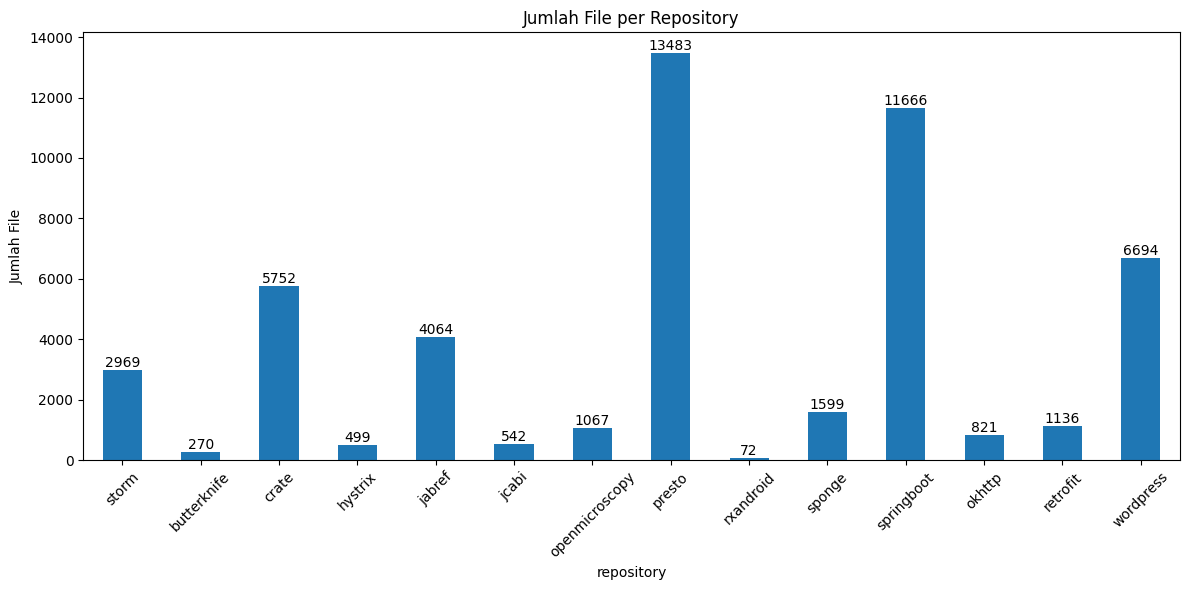

In [4]:
import matplotlib.pyplot as plt

ax = df.plot(kind='bar', x='repository', y='total_files', figsize=(12,6), legend=False)

# Tambahkan angka di atas setiap batang
for i, value in enumerate(df['total_files']):
    ax.text(i, value, str(value), ha='center', va='bottom')

plt.xticks(rotation=45)
plt.ylabel("Jumlah File")
plt.title("Jumlah File per Repository")
plt.tight_layout()
plt.show()